## 1. Introduction

### Task: Baseline Training Notebook — BirdCLEF+ 2026

#### Research Context
- Paper: [Tackling Domain Shift in Bird Audio Classification via Transfer Learning and Semi-Supervised Distillation: A Case Study on BirdCLEF+ 2025 (Sydorskyi & Gonçalves, 2025)](https://ceur-ws.org/Vol-4038/paper_256.pdf)
- This notebook investigates transfer learning with CNN backbones (EfficientNet family) pretrained on ImageNet, fine-tuned for multi-label bioacoustic classification across 234 species (birds, amphibians, mammals, reptiles, insects) from 5-second audio chunks in BirdCLEF+ 2026.

#### Objectives
- Compare three EfficientNet variants on macro ROC-AUC and macro F1 (threshold = 0.5) using 3-fold cross-validation:

  | Model | timm ID |
  |---|---|
  | EfficientNetV2-S | `tf_efficientnetv2_s.in21k_ft_in1k` |
  | EfficientNetB0 | `tf_efficientnet_b0.ns_jft_in1k` |
  | EfficientNetB3 | `tf_efficientnet_b3.ns_jft_in1k` |

- Gain insight into whether a larger backbone (EfficientNetV2-S) justifies its additional compute cost over lighter alternatives (B0, B3) for this task
- Establish a stable preprocessing and baseline modelling pipeline 
    - converting raw audio to log-Mel spectrograms (128 mel bands, 32 kHz), 
    - training with AdamW + cosine LR schedule + early stopping as the foundation for future experiments in this project

#### Research Question
- Which EfficientNet variant provides the most effective and reliable baseline for BirdCLEF+ 2026, considering macro ROC-AUC, macro F1, and leaderboard performance?


## 2. Setup

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import timm
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

UTILS    = '/kaggle/input/datasets/tsapalyu/birdclef2026-utils'
UPSAMPLE = '/kaggle/input/datasets/tsapalyu/birdclef2026-upsamples/train_upsampled_species' 

SEG_DIR  = f'{UPSAMPLE}/train_upsampled_species'   # pre-extracted 5-s clips

CHECKPOINT_DIR = '/kaggle/input/birdclef2026-baseline-weights'

NUM_FOLDS = 3

sys.path.append(UTILS)

from birdclef_utils.dataset import UpsampledSpeciesDataset
from birdclef_utils.constants import NUM_CLASSES

_base = {
    'batch_size':    64,
    'accum_steps':   1,
    'num_workers':   4,
    'lr':            1e-3,
    'weight_decay':  1e-5,
    'max_epochs':    20,
    'patience':      5,
    'num_classes':   NUM_CLASSES,
    'use_amp':       False,
    # loss: 1.0 * BCE + 1.0 * SigmoidFocalLoss (alpha=0.25, gamma=2)
    'bce_weight':    1.0,
    'focal_weight':  1.0,
    'focal_alpha':   0.25,
    'focal_gamma':   2.0,
}

CONFIGS = {
    'effnetv2s': {**_base,
        'model_name': 'tf_efficientnetv2_s.in21k_ft_in1k',
        'model_key':  'effnetv2s',
    },
    'effnetb0': {**_base,
        'model_name': 'tf_efficientnet_b0.ns_jft_in1k',
        'model_key':  'effnetb0',
    },
    'effnetb3': {**_base,
        'model_name': 'tf_efficientnet_b3.ns_jft_in1k',
        'model_key':  'effnetb3',
    },
}

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'CPU'}")
print(f"Models to compare: {list(CONFIGS.keys())}")

Device: Tesla T4
Models to compare: ['effnetv2s', 'effnetb0', 'effnetb3']


## 3 & 4. Data Loading & Exploration and Preprocessing

In [2]:
seg_df = pd.read_csv(f'{SEG_DIR}/species_segment_index.csv')
with open(f'{UTILS}/label2idx.json') as f:
    label2idx = json.load(f)

# Verify SEG_DIR exists and a sample of segment files are reachable
assert os.path.isdir(SEG_DIR), f"SEG_DIR not found: {SEG_DIR}"
_sample_paths = seg_df['dest_path'].head(5).tolist()
_missing = [
    p for p in _sample_paths
    if not os.path.exists(os.path.join(SEG_DIR, *p.split('/')[2:]))
]
if _missing:
    print(f"WARNING: {len(_missing)}/5 sampled segment files not found in {SEG_DIR!r}:")
    for p in _missing:
        print(f"  {p}")
else:
    print(f"seg segments: {len(seg_df):,}  |  {seg_df['assigned_species'].nunique()} species  |  {NUM_CLASSES} classes  |  path check OK")

def build_loaders(fold, batch_size=32, num_workers=4):
    """Build train/val DataLoaders for one fold using UpsampledSpeciesDataset."""
    train_df = seg_df[
        (seg_df['fold'] != fold) & seg_df['assigned_species'].isin(label2idx)
    ].reset_index(drop=True)
    val_df = seg_df[
        (seg_df['fold'] == fold) & seg_df['assigned_species'].isin(label2idx)
    ].reset_index(drop=True)

    train_ds = UpsampledSpeciesDataset(train_df, SEG_DIR, label2idx, mode='train')
    val_ds   = UpsampledSpeciesDataset(val_df,   SEG_DIR, label2idx, mode='val')

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True, drop_last=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
    )

    return train_loader, val_loader, val_ds


# Sanity check: verify batch shapes for fold 0 before building models
train_loader, val_loader, val_ds = build_loaders(fold=0, batch_size=64)
specs, labels = next(iter(train_loader))
print(f"spec batch:  {specs.shape}")
print(f"label batch: {labels.shape}")
print(f"avg species per sample: {labels.sum(dim=1).mean():.2f}")

seg segments: 74,385  |  225 species  |  234 classes  |  path check OK
spec batch:  torch.Size([64, 1, 128, 313])
label batch: torch.Size([64, 234])
avg species per sample: 1.03


## 5. Model Definition

Models are built using a CNN backbone from timm with:
- ImageNet pretrained weights
- Single-channel spectrogram input (`in_chans=1`)
- 234-output multi-label classification head

Three backbones are compared:
- **EfficientNetV2-S** (`tf_efficientnetv2_s.in21k_ft_in1k`) — (as per the paper)
- **EfficientNetB0** (`tf_efficientnet_b0.ns_jft_in1k`) — lighter, faster alternative
- **EfficientNetB3** (`tf_efficientnet_b3.ns_jft_in1k`) — lighter, faster alternative

In [3]:
def build_model(cfg):
    model = timm.create_model(
        cfg['model_name'],
        pretrained=True,
        num_classes=cfg['num_classes'],
        in_chans=1,
    )
    return model.to(DEVICE)

## 6. Training

In [4]:
def train_one_epoch(model, loader, optimizer, criterion, cfg):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()

    for step, (specs, labels) in enumerate(loader):
        specs  = specs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # forward
        logits = model(specs)
        loss = criterion(logits, labels)

        # backward (with gradient accumulation)
        (loss / cfg['accum_steps']).backward()
        if (step + 1) % cfg['accum_steps'] == 0:
            optimizer.step()
            optimizer.zero_grad()

        running_loss += loss.item()

    return running_loss / len(loader)


### Metrics

In [5]:
def macro_roc_auc(y_true, y_pred):
    """Mean per-class ROC-AUC, skipping classes with no positive (or no
    negative) labels — AUC is undefined for those."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    aucs = []
    for c in range(y_true.shape[1]):
        col = y_true[:, c]
        if col.sum() == 0 or col.sum() == len(col):
            continue
        aucs.append(roc_auc_score(col, y_pred[:, c]))
    return float(np.mean(aucs)) if aucs else float('nan')


def macro_f1(y_true, y_pred, threshold=0.5):
    """Macro-averaged F1, restricted to classes that have at least one
    positive label in y_true (undefined classes are skipped, not zeroed)."""
    y_true = np.asarray(y_true)
    y_binary = (np.asarray(y_pred) >= threshold).astype(int)
    valid = y_true.sum(axis=0) > 0
    if not valid.any():
        return float('nan')
    return float(f1_score(y_true[:, valid], y_binary[:, valid],
                          average='macro', zero_division=0))

### Loss Function

Combined `1.0 · BCE + 1.0 · SigmoidFocalLoss`, following the paper (Section 5.2).

Weights and gamma are set in `_base` and can be overridden per model in `CONFIGS`.

In [6]:
class CombinedBCEFocalLoss(nn.Module):
    """1.0 · BCEWithLogitsLoss + 1.0 · torchvision SigmoidFocalLoss."""
    def __init__(self, bce_weight=1.0, focal_weight=1.0, alpha=0.25, gamma=2.0):
        super().__init__()
        self.bce_weight   = bce_weight
        self.focal_weight = focal_weight
        self.alpha        = alpha
        self.gamma        = gamma
        self.bce          = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss   = self.bce(logits, targets)
        focal_loss = torchvision.ops.sigmoid_focal_loss(
            inputs=logits,
            targets=targets,
            alpha=self.alpha,
            gamma=self.gamma,
            reduction='mean',
        )
        return self.bce_weight * bce_loss + self.focal_weight * focal_loss


def build_criterion(cfg):
    return CombinedBCEFocalLoss(
        bce_weight=cfg.get('bce_weight', 1.0),
        focal_weight=cfg.get('focal_weight', 1.0),
        alpha=cfg.get('focal_alpha', 0.25),
        gamma=cfg.get('focal_gamma', 2.0),
    )

### Validation

In [7]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for specs, labels in loader:
        specs = specs.to(DEVICE, non_blocking=True)
        probs = torch.sigmoid(model(specs))
        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())
    return np.vstack(all_preds), np.vstack(all_labels)

### Fold Training

In [8]:
def train_fold(fold, cfg):
    model_key = cfg['model_key']
    print(f"\n{'='*55}\n{model_key.upper()}  —  FOLD {fold}\n{'='*55}")

    train_loader, val_loader, val_ds = build_loaders(
        fold, batch_size=cfg['batch_size'], num_workers=cfg['num_workers'],
    )

    print(f"Train samples: {len(train_loader.dataset)}")
    print(f"Val samples:   {len(val_ds)}")

    model     = build_model(cfg)
    criterion = build_criterion(cfg)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg['max_epochs'],
    )

    ckpt_path = f'/kaggle/working/{model_key}_fold{fold}_last.pth'
    start_epoch = 0
    best_auc = 0.0
    epochs_no_improve = 0

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch       = ckpt['epoch'] + 1
        best_auc          = ckpt['best_auc']
        epochs_no_improve = ckpt['epochs_no_improve']
        print(f"Resuming {model_key} fold {fold} from epoch {start_epoch} "
              f"(best AUC so far {best_auc:.4f})")
    else:
        print(f"No checkpoint found - training {model_key} fold {fold} from scratch.")

    for epoch in range(start_epoch, cfg['max_epochs']):
        t0 = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer,
                                     criterion, cfg)

        preds, labels = evaluate(model, val_loader)
        val_auc = macro_roc_auc(labels, preds)

        scheduler.step()

        print(f"  epoch {epoch:2d} | loss {train_loss:.4f} | "
              f"val AUC {val_auc:.4f} | {time.time()-t0:.0f}s")

        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_auc':             best_auc,
            'epochs_no_improve':    epochs_no_improve,
            'val_auc':              val_auc,
            'model_name':           cfg['model_name'],
            'model_key':            model_key,
            'num_classes':          cfg['num_classes'],
            'in_chans':             1,
        }, f'/kaggle/working/{model_key}_fold{fold}_last.pth')

        if val_auc > best_auc:
            best_auc = val_auc
            epochs_no_improve = 0
            torch.save({'model_state_dict': model.state_dict(),
                        'epoch': epoch, 'val_auc': val_auc},
                       f'/kaggle/working/{model_key}_fold{fold}_best.pth')
            print(f"    -> new best ({best_auc:.4f})")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= cfg['patience']:
            print(f"  early stopping (best val AUC {best_auc:.4f})")
            break

    return best_auc

In [9]:
# --- Training control ---
# It's for manual run to avoid long running section.
# Set MODEL_KEY to select which backbone to train.
# Set FOLD to select which fold to run.
# Run this cell once per fold per model (or loop over both if compute allows).
SMOKE_TEST = False
MODEL_KEY  = 'effnetb3'   # 'effnetv2s' | 'effnetb0' | 'effnetb3'
FOLD       = 2              # 0 | 1 | 2

cfg = CONFIGS[MODEL_KEY]

if SMOKE_TEST:
    smoke_cfg = dict(cfg, max_epochs=1)
    print(f"SMOKE TEST: one epoch, fold {FOLD}, model {MODEL_KEY}.")
    train_fold(fold=FOLD, cfg=smoke_cfg)
else:
    best = train_fold(fold=FOLD, cfg=cfg)
    print(f"\n{MODEL_KEY} fold {FOLD} best val AUC: {best:.4f}")

# To run continuously all models all folds
# SMOKE_TEST = False

# for MODEL_KEY, cfg in CONFIGS.items():
#    for FOLD in range(NUM_FOLDS):
#        if SMOKE_TEST:
#            smoke_cfg = dict(cfg, max_epochs=1)
#            print(f"SMOKE TEST: one epoch, fold {FOLD}, model {MODEL_KEY}.")
#            train_fold(fold=FOLD, cfg=smoke_cfg)
#        else:
#            best = train_fold(fold=FOLD, cfg=cfg)
#            print(f"\n{MODEL_KEY} fold {FOLD} best val AUC: {best:.4f}")


EFFNETB3  —  FOLD 2
Train samples: 49645
Val samples:   24740


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

No checkpoint found - training effnetb3 fold 2 from scratch.
  epoch  0 | loss 0.0315 | val AUC 0.9427 | 618s
    -> new best (0.9427)
  epoch  1 | loss 0.0154 | val AUC 0.9720 | 589s
    -> new best (0.9720)
  epoch  2 | loss 0.0115 | val AUC 0.9784 | 593s
    -> new best (0.9784)
  epoch  3 | loss 0.0090 | val AUC 0.9806 | 588s
    -> new best (0.9806)
  epoch  4 | loss 0.0070 | val AUC 0.9823 | 587s
    -> new best (0.9823)
  epoch  5 | loss 0.0052 | val AUC 0.9834 | 587s
    -> new best (0.9834)
  epoch  6 | loss 0.0038 | val AUC 0.9830 | 590s
  epoch  7 | loss 0.0026 | val AUC 0.9830 | 589s
  epoch  8 | loss 0.0017 | val AUC 0.9827 | 593s
  epoch  9 | loss 0.0012 | val AUC 0.9824 | 588s
  epoch 10 | loss 0.0008 | val AUC 0.9823 | 587s
  early stopping (best val AUC 0.9834)

effnetb3 fold 2 best val AUC: 0.9834


## 7. Evaluation

### Evaluation Plan
- Load best checkpoint per model per fold from saved weights
- Evaluate on held-out validation folds (3-fold CV)
- Compute macro ROC-AUC and macro F1 (threshold = 0.5)

In [9]:
def load_fold_model(checkpoint_path, cfg):
    """Rebuild a trained model from a saved checkpoint."""
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    model = timm.create_model(
        cfg['model_name'],
        pretrained=False,
        num_classes=cfg['num_classes'],
        in_chans=1,
    )
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(DEVICE).eval()
    return model, ckpt

In [10]:
all_results = {}

for model_key, cfg in CONFIGS.items():
    fold_rows = []
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_key}  ({cfg['model_name']})")
    print(f"{'='*60}")

    for fold in range(NUM_FOLDS):
        ckpt_path = os.path.join(CHECKPOINT_DIR,
                                 f'{model_key}_fold{fold}_last.pth')
        if not os.path.exists(ckpt_path):
            print(f"  Fold {fold}: checkpoint not found, skipping.")
            continue

        print(f"\n  --- Fold {fold} ---")
        model, ckpt = load_fold_model(ckpt_path, cfg)
        print(f"  loaded epoch {ckpt['epoch']}, "
              f"training-time val AUC {ckpt['val_auc']:.4f}")

        _, val_loader, _ = build_loaders(
            fold,
            batch_size=cfg['batch_size'],
            num_workers=cfg['num_workers'],
        )

        preds, labels = evaluate(model, val_loader)
        auc = macro_roc_auc(labels, preds)
        f1  = macro_f1(labels, preds)
        print(f"  val AUC: {auc:.4f}  |  val F1 (t=0.5): {f1:.4f}")

        fold_rows.append({
            'fold':    fold,
            'val_AUC': auc,
            'val_F1':  f1,
            'n_val':   len(labels),
        })

        del model
        torch.cuda.empty_cache()

    all_results[model_key] = pd.DataFrame(fold_rows)


# --- Comparison table ---
print("\n" + "=" * 65)
print("Model Comparison — macro ROC-AUC vs macro F1 (threshold = 0.5)")
print("=" * 65)

summary_rows = []
for model_key, df in all_results.items():
    if df.empty:
        continue
    summary_rows.append({
        'model':      model_key,
        'mean_AUC':   df['val_AUC'].mean(),
        'std_AUC':    df['val_AUC'].std(ddof=1),
        'mean_F1':    df['val_F1'].mean(),
        'std_F1':     df['val_F1'].std(ddof=1),
        'folds_done': len(df),
    })

comparison_df = pd.DataFrame(summary_rows)
print(comparison_df.to_string(index=False, float_format='%.4f'))

for model_key, df in all_results.items():
    if not df.empty:
        df.to_csv(f'/kaggle/working/cv_summary_{model_key}.csv', index=False)
comparison_df.to_csv('/kaggle/working/cv_comparison.csv', index=False)
print(f"\nSaved cv_comparison.csv and per-model summaries to /kaggle/working/")


Evaluating: effnetv2s  (tf_efficientnetv2_s.in21k_ft_in1k)

  --- Fold 0 ---
  loaded epoch 12, training-time val AUC 0.9832
  val AUC: 0.9832  |  val F1 (t=0.5): 0.8380

  --- Fold 1 ---
  loaded epoch 11, training-time val AUC 0.9842
  val AUC: 0.9842  |  val F1 (t=0.5): 0.8346

  --- Fold 2 ---
  loaded epoch 14, training-time val AUC 0.9826
  val AUC: 0.9826  |  val F1 (t=0.5): 0.8510

Evaluating: effnetb0  (tf_efficientnet_b0.ns_jft_in1k)

  --- Fold 0 ---
  loaded epoch 12, training-time val AUC 0.9796
  val AUC: 0.9796  |  val F1 (t=0.5): 0.8006

  --- Fold 1 ---
  loaded epoch 12, training-time val AUC 0.9816
  val AUC: 0.9816  |  val F1 (t=0.5): 0.8046

  --- Fold 2 ---
  loaded epoch 12, training-time val AUC 0.9805
  val AUC: 0.9805  |  val F1 (t=0.5): 0.8048

Evaluating: effnetb3  (tf_efficientnet_b3.ns_jft_in1k)

  --- Fold 0 ---
  loaded epoch 11, training-time val AUC 0.9802
  val AUC: 0.9802  |  val F1 (t=0.5): 0.8018

  --- Fold 1 ---
  loaded epoch 10, training-time 

### Note: No Held-Out Test Set

BirdCLEF+ 2026 is a Kaggle competition where the test set consists of hidden soundscape recordings which means that participants never receive the audio files or ground-truth labels. Predictions are submitted to Kaggle's scoring server, which returns a public leaderboard score (macro ROC-AUC) computed on a subset of the hidden test data.

This means local evaluation is only possible on the labeled training data. We follow the paper (Sydorskyi & Gonçalves, 2025) and use 3-fold cross-validation on the training data. The fold-level macro ROC-AUC and macro F1 reported here are the best available local signal and the true test performance will only be revealed via Kaggle submission.

## 8. Comparison & Analysis

### 8.1 Comparison Table & Bar Charts

Model Comparison — 3-fold CV (mean ± std)
Model            AUC mean   AUC std   F1 mean   F1 std
-------------------------------------------------------
effnetb0           0.9806    0.0010    0.8033   0.0023
effnetb3           0.9818    0.0014    0.8078   0.0056
effnetv2s          0.9833    0.0008    0.8412   0.0086


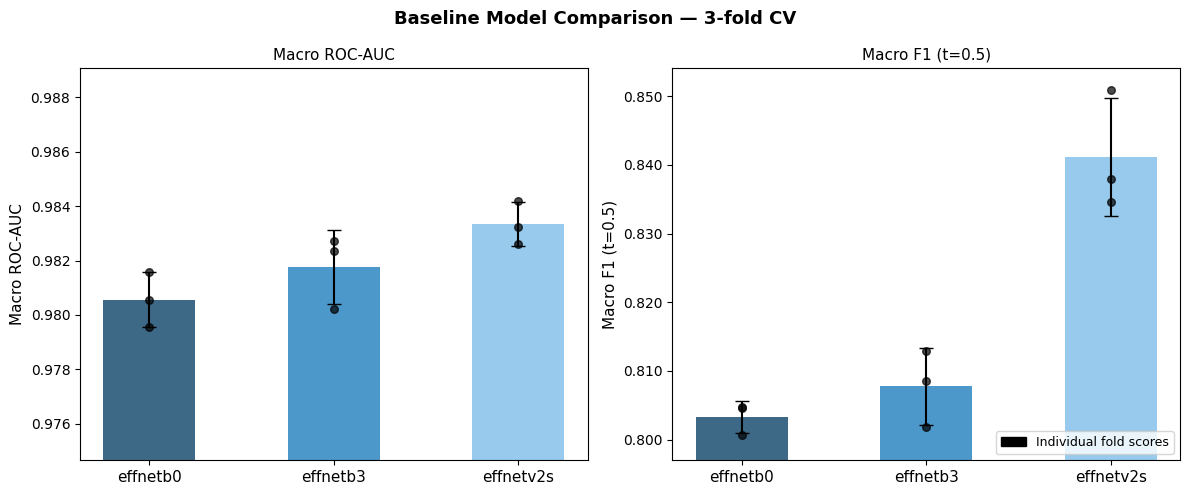

In [8]:
MODEL_ORDER = ['effnetb0', 'effnetb3', 'effnetv2s']
colors = ['#1B4F72', '#2E86C1', '#85C1E9']

# Load results saved by section 7
comparison_df = pd.read_csv('/kaggle/working/cv_comparison.csv')
comparison_df['model'] = pd.Categorical(comparison_df['model'], categories=MODEL_ORDER, ordered=True)
comparison_df = comparison_df.sort_values('model').reset_index(drop=True)

all_results = {
    model_key: pd.read_csv(f'/kaggle/working/cv_summary_{model_key}.csv')
    for model_key in MODEL_ORDER
    if os.path.exists(f'/kaggle/working/cv_summary_{model_key}.csv')
}

# --- Comparison table ---
print("Model Comparison — 3-fold CV (mean ± std)")
print("=" * 55)
print(f"{'Model':<14} {'AUC mean':>10} {'AUC std':>9} {'F1 mean':>9} {'F1 std':>8}")
print("-" * 55)
best_auc_model = comparison_df.loc[comparison_df['mean_AUC'].idxmax(), 'model']
for _, row in comparison_df.iterrows():
    print(f"{row['model']:<14} {row['mean_AUC']:>10.4f} {row['std_AUC']:>9.4f} "
          f"{row['mean_F1']:>9.4f} {row['std_F1']:>8.4f}")

# --- Bar charts ---
models    = comparison_df['model'].tolist()
x         = range(len(models))
bar_width = 0.5
#colors    = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Baseline Model Comparison — 3-fold CV', fontsize=13, fontweight='bold')

for ax, metric, label in [
    (axes[0], 'AUC', 'Macro ROC-AUC'),
    (axes[1], 'F1',  'Macro F1 (t=0.5)'),
]:
    means = comparison_df[f'mean_{metric}'].values
    stds  = comparison_df[f'std_{metric}'].values

    ax.bar(x, means, width=bar_width, yerr=stds, capsize=5,
           color=colors[:len(models)], alpha=0.85, error_kw={'linewidth': 1.5})

    for i, model_key in enumerate(models):
        df = all_results.get(model_key)
        if df is not None and not df.empty:
            fold_vals = df[f'val_{metric}'].values
            ax.scatter([i] * len(fold_vals), fold_vals,
                       color='black', zorder=5, s=30, alpha=0.7)

    ax.set_xticks(list(x))
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=11)
    y_min = min(means - stds) * 0.995
    y_max = max(means + stds) * 1.005
    ax.set_ylim(y_min, y_max)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))

dot_legend = mpatches.Patch(color='black', label='Individual fold scores')
axes[1].legend(handles=[dot_legend], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Learning Curves

Loaded from `{model_key}_fold{fold}_history.json` in the baseline-weights dataset. We saved this log file during each fold training. 
Each line is one fold; the vertical dashed line marks where early stopping fired.

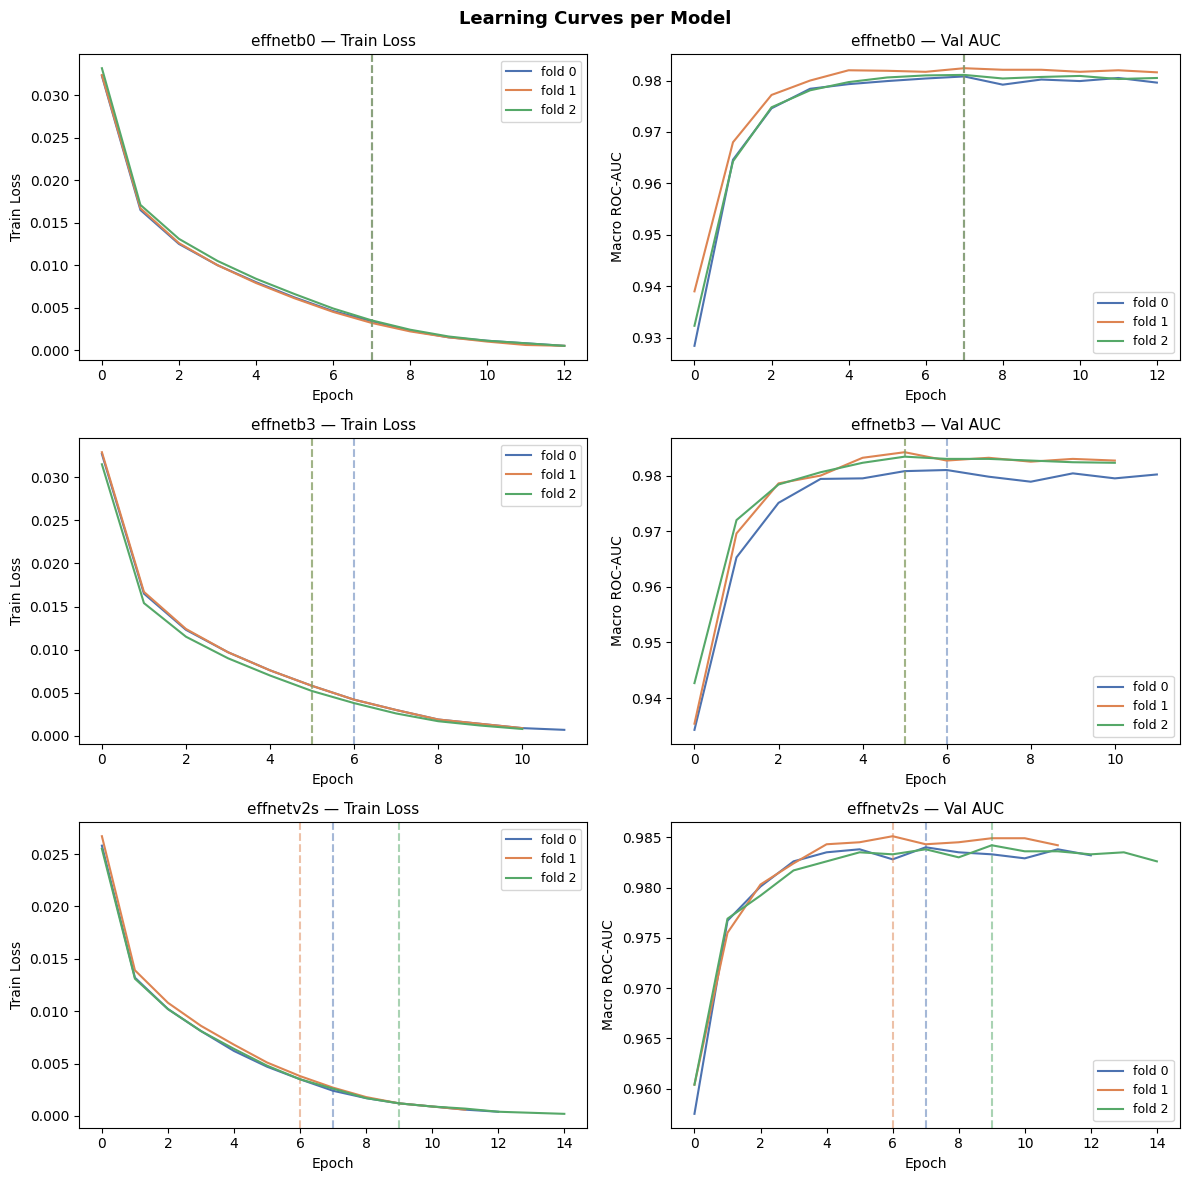

In [6]:
CHECKPOINT_DIR = '/kaggle/input/birdclef2026-baseline-weights'
fold_colors = ['#4C72B0', '#DD8452', '#55A868']
fig, axes = plt.subplots(len(MODEL_ORDER), 2, figsize=(12, 4 * len(MODEL_ORDER)))
fig.suptitle('Learning Curves per Model', fontsize=13, fontweight='bold')

for row_idx, model_key in enumerate(MODEL_ORDER):
    ax_loss = axes[row_idx, 0]
    ax_auc  = axes[row_idx, 1]

    ax_loss.set_title(f'{model_key} — Train Loss', fontsize=11)
    ax_auc.set_title( f'{model_key} — Val AUC',    fontsize=11)
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Train Loss')
    ax_auc.set_xlabel('Epoch');  ax_auc.set_ylabel('Macro ROC-AUC')

    any_loaded = False
    for fold in range(NUM_FOLDS):
        history_path = os.path.join(
            CHECKPOINT_DIR, f'{model_key}_fold{fold}_history.json'
        )
        if not os.path.exists(history_path):
            continue

        with open(history_path) as f:
            history = json.load(f)

        epochs     = [e['epoch']      for e in history]
        train_loss = [e['train_loss'] for e in history]
        val_auc    = [e['val_auc']    for e in history]
        best_epoch = epochs[val_auc.index(max(val_auc))]
        color      = fold_colors[fold % len(fold_colors)]

        ax_loss.plot(epochs, train_loss, color=color, label=f'fold {fold}')
        ax_auc.plot( epochs, val_auc,    color=color, label=f'fold {fold}')
        ax_loss.axvline(best_epoch, color=color, linestyle='--', alpha=0.5)
        ax_auc.axvline( best_epoch, color=color, linestyle='--', alpha=0.5)
        any_loaded = True

    if not any_loaded:
        ax_loss.text(0.5, 0.5, 'No history files found',
                     ha='center', va='center', transform=ax_loss.transAxes)
        ax_auc.text( 0.5, 0.5, 'No history files found',
                     ha='center', va='center', transform=ax_auc.transAxes)
    else:
        ax_loss.legend(fontsize=9)
        ax_auc.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Kaggle Submission Scores

Public and private leaderboard scores (macro ROC-AUC) from submitting each `_last` checkpoint individually. After we submitted our models on Kaggle, we received both public and private scores and we saved them in the csv file.

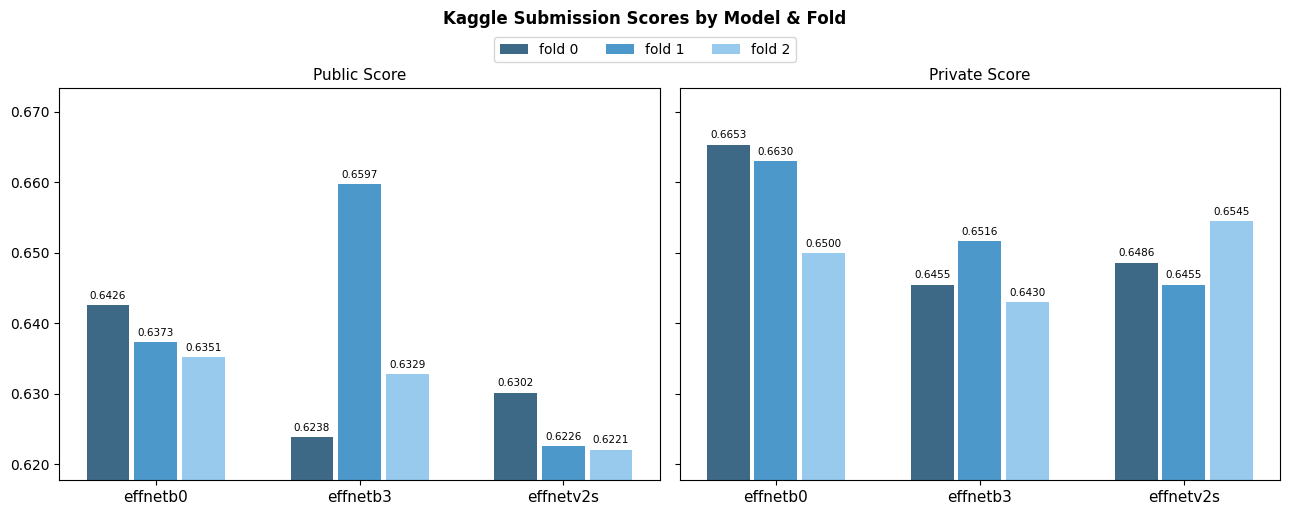

In [9]:
SCORES_PATH = f'{CHECKPOINT_DIR}/submission_score.csv' 


scores_df = pd.read_csv(SCORES_PATH)
scores_df['model_key'] = scores_df['model'].str.extract(r'^(effnet\w+?)_fold')
scores_df['fold']      = scores_df['model'].str.extract(r'_fold(\d)_').astype(int)
scores_df['model_key'] = pd.Categorical(scores_df['model_key'], categories=MODEL_ORDER, ordered=True)
scores_df = scores_df.sort_values('model_key').reset_index(drop=True)

model_keys  = MODEL_ORDER
n_models    = len(model_keys)
n_folds     = scores_df['fold'].nunique()
group_width = 0.7
bar_width   = group_width / n_folds
offsets     = [(i - (n_folds - 1) / 2) * bar_width for i in range(n_folds)]

all_scores = pd.concat([scores_df['public_score'], scores_df['private_score']])
y_min = all_scores.min() * 0.993
y_max = all_scores.max() * 1.012

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('Kaggle Submission Scores by Model & Fold', fontsize=12, fontweight='bold', y=1.02)

legend_handles = []
for ax, score_col, title in [
    (axes[0], 'public_score',  'Public Score'),
    (axes[1], 'private_score', 'Private Score'),
]:
    for fold in range(n_folds):
        fold_df = scores_df[scores_df['fold'] == fold].set_index('model_key')
        x_pos   = [model_keys.index(mk) + offsets[fold] for mk in model_keys]
        values  = [fold_df.loc[mk, score_col] if mk in fold_df.index else 0 for mk in model_keys]
        bars = ax.bar(x_pos, values, width=bar_width * 0.9,
                      color=fold_colors[fold], alpha=0.85, label=f'fold {fold}')
        ax.bar_label(bars, fmt='%.4f', fontsize=7.5, padding=3)
        if ax is axes[0]:
            legend_handles.append(bars)

    ax.set_xticks(range(n_models))
    ax.set_xticklabels(model_keys, fontsize=11)
    ax.set_ylabel('')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(y_min, y_max)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))

fig.legend(handles=legend_handles,
           labels=[f'fold {i}' for i in range(n_folds)],
           loc='upper center', ncol=n_folds, fontsize=10,
           bbox_to_anchor=(0.5, 0.98))

plt.tight_layout()
plt.savefig('/kaggle/working/submission_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Discussion

Among the three architectures evaluated, EfficientNet-B0 demonstrated the most consistent performance on the Kaggle public leaderboard across all folds. Its public scores ranged from 0.6351 to 0.6426, showing relatively low fold-to-fold variability. In contrast, EfficientNet-B3 exhibited substantial instability, with scores ranging from 0.6238 to 0.6597, while EfficientNetV2-S also showed noticeable variation across folds (0.6221–0.6302).

Although EfficientNetV2-S achieved the highest cross-validation ROC-AUC and F1 scores, its leaderboard performance was less consistent. For pseudo-label generation, model reliability and robustness are particularly important because prediction errors can be propagated into subsequent training stages. Therefore, we prioritized leaderboard stability over cross-validation performance.

Based on these observations, **EfficientNet-B0** was selected as the pseudo-labeling model, and specifically **Fold 0** was chosen since it achieved the strongest public leaderboard score (0.6426) among the EfficientNet-B0 folds while maintaining the model's overall stable behavior. This fold was considered the most reliable candidate for generating high-quality pseudo-labels for the next stage of training.

## 10. References

Data source: https://www.kaggle.com/competitions/birdclef-2026/data

Confiugration settings: https://github.com/VSydorskyy/BirdCLEF_2025_2nd_place (from Reference Paper)